# Evaluating Planners on the nuPlan World

[nuPlan](https://www.nuplan.org/) is a closed-loop planning benchmark built on ~1200 h of real
driving logs. `POMDPPlanners/environments/nuplan_pomdp/` adapts it into a POMDP so planners can be
scored on it with the same machinery used for every other environment in the package.

This notebook is about **evaluation**: driving the nuPlan world with a planner and reading the
driving-quality metrics it reports — one episode at a time, then in batch with confidence intervals
through `LocalSimulationsAPI`.

## The two-environment design

nuPlan is *forward-only*: a `Simulation` advances one true state per call and cannot be re-run from
an arbitrary injected state, nor queried for a transition density. So it cannot be the planner's
generative model — it is only the **world**. The planner carries its own model.

| Role | Class | What it does |
|------|-------|--------------|
| **World** | `NuPlanPOMDP` | Ground truth. Ticks the nuPlan simulation once per step and returns the true next state, the raw `{ego, agents}` observation, the reward, and the terminal (collision) flag. |
| **Model** | `KinematicNuPlanModelPOMDP` | What the planner searches inside: a kinematic-bicycle ego transition, a factored per-agent observation model (range gate, occlusion, missed detections, pose noise), and the same driving-quality reward. |
| **Belief** | `PerceivedAgentsBelief` | Particle filter over the ego state that stamps the *perceived* agent block onto every particle, so vehicles appearing mid-episode get acquired. |

`EpisodeRunner` wires these together: the executed trajectory comes from the world, while the belief
update runs on `policy.environment` (the model). Perception lives **only** on the model — the world
emits raw ground truth and `model.encode_observation` degrades it.

> **Backend.** The real world needs the `nuplan-devkit` *and* a scenario from the nuPlan dataset.
> §2 defines a synthetic world that speaks the exact same schema so this notebook runs anywhere;
> §6 is the one-argument swap to real scenarios.

## 1. The schema and the metrics

State and observation share one fixed layout, so world and model agree by construction.

- **State** `[ego(7) | agent_slots(K×5) | light(5)]`, ego = `[x, y, yaw(rad), vx, vy, lat, heading_err]`,
  each agent slot = `[present, rel_x, rel_y, rel_yaw, rel_speed]` in the **ego frame**
  (`rel_x` forward, `rel_y` left).
- **Observation** is a dict: `"ego"` (proprioception) and `"agents"` (the flattened slots).
- **Actions** are indices into discrete `(acceleration, steering_angle)` presets.

`get_metric_names()` is what the evaluation ultimately reports.

In [1]:
import numpy as np

from POMDPPlanners.environments.nuplan_pomdp.nuplan_pomdp import (
    AGENT_SLOT_WIDTH,
    DEFAULT_ACTION_PRESETS,
    EGO_STATE_WIDTH,
    LIGHT_SLOT_WIDTH,
    NuPlanPOMDP,
    assemble_state,
    relative_agent_row,
)

GAMMA = 0.95        # shared by the world and the model (the episode runner enforces this)
DT = 0.1            # nuPlan iteration length, seconds
K = 3               # tracked-agent slots carried in state/observation
STATE_WIDTH = EGO_STATE_WIDTH + K * AGENT_SLOT_WIDTH + LIGHT_SLOT_WIDTH

print("state width      :", STATE_WIDTH)
print("action presets   :", DEFAULT_ACTION_PRESETS)  # (acceleration m/s^2, steering rad)
print("metrics reported :")
for name in NuPlanPOMDP(discount_factor=GAMMA, max_tracked_agents=K).get_metric_names():
    print("   -", name)

2026-08-01 15:23:04,850 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:187 - Initializing NuPlanPOMDP environment with discount factor 0.95


state width      : 27
action presets   : ((1.5, 0.0), (0.0, -0.3), (0.0, 0.3), (-3.0, 0.0))
metrics reported :
   - collision_rate
   - average_progress
   - average_speed
   - near_miss_count
   - min_vehicle_distance


## 2. A world backend that runs anywhere

`NuPlanPOMDP` talks to the simulator through one seam — `_get_session()`, which must return an object
with `reset()` and `step(acceleration, steering_angle)`. The unit tests substitute a scripted fake
there; here we substitute a small **synthetic** session that emits the exact nuPlan state/observation
schema: an ego propagated by a kinematic bicycle, a slow lead vehicle in-lane, and a faster vehicle in
the adjacent lane. Everything downstream — reward, terminal, metrics, the episode runner, the
simulations API — is the real `NuPlanPOMDP` code path.

In [2]:
from typing import Any, Dict, Optional, Tuple


class SyntheticNuPlanSession:
    """Forward-only stand-in for a live nuPlan Simulation, in the exact nuPlan schema."""

    def __init__(self, max_tracked_agents: int, dt: float, collision_distance: float) -> None:
        self._k = max_tracked_agents
        self._dt = dt
        self._collision_distance = collision_distance
        self._wheelbase = 2.8
        self._ego = np.zeros(EGO_STATE_WIDTH)
        self._agents = np.zeros((2, 4))  # world rows [x, y, yaw, speed]

    def reset(self, seed: Optional[int] = None) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
        rng = np.random.default_rng(seed)
        self._ego = np.array([0.0, 0.0, 0.0, 5.0, 0.0, 0.0, 0.0])  # 5 m/s at the origin
        self._agents = np.array(
            [
                [14.0 + rng.normal(0.0, 1.5), 0.0, 0.0, 1.0],  # slow lead vehicle, same lane
                [24.0 + rng.normal(0.0, 2.0), 3.7, 0.0, 4.0],  # faster vehicle, left lane
            ]
        )
        state = self._state()
        return state, self._observation(state)

    def step(self, acceleration: float, steering_angle: float):
        self._advance_ego(acceleration, steering_angle)
        self._agents[:, 0] += self._agents[:, 3] * self._dt
        state = self._state()
        return state, self._observation(state), self._collided(state)

    def _advance_ego(self, acceleration: float, steering_angle: float) -> None:
        x, y, yaw, vel_x, vel_y = self._ego[:5]
        speed = max(0.0, float(np.hypot(vel_x, vel_y)) + acceleration * self._dt)
        yaw_next = yaw + (speed / self._wheelbase) * np.tan(steering_angle) * self._dt
        vx, vy = speed * np.cos(yaw_next), speed * np.sin(yaw_next)
        lateral = y + vy * self._dt  # offset from the y = 0 route baseline
        self._ego = np.array(
            [x + vx * self._dt, lateral, yaw_next, vx, vy, lateral, yaw_next]
        )

    def _state(self) -> np.ndarray:
        ego_x, ego_y, ego_yaw = float(self._ego[0]), float(self._ego[1]), float(self._ego[2])
        rows = [
            relative_agent_row(ego_x, ego_y, ego_yaw, x, y, yaw, speed)
            for x, y, yaw, speed in self._agents
        ]
        return assemble_state(self._ego, rows, self._k)

    def _observation(self, state: np.ndarray) -> Dict[str, np.ndarray]:
        end = EGO_STATE_WIDTH + self._k * AGENT_SLOT_WIDTH
        return {"ego": state[:EGO_STATE_WIDTH].copy(), "agents": state[EGO_STATE_WIDTH:end].copy()}

    def _collided(self, state: np.ndarray) -> bool:
        end = EGO_STATE_WIDTH + self._k * AGENT_SLOT_WIDTH
        rows = state[EGO_STATE_WIDTH:end].reshape(self._k, AGENT_SLOT_WIDTH)
        present = rows[rows[:, 0] == 1.0]
        if not len(present):
            return False
        return bool(np.min(np.hypot(present[:, 1], present[:, 2])) < self._collision_distance)


class SyntheticNuPlanPOMDP(NuPlanPOMDP):
    """A NuPlanPOMDP whose live session is the synthetic one (the `_get_session` seam)."""

    def __init__(self, **kwargs: Any) -> None:
        super().__init__(**kwargs)
        self._synthetic: Optional[SyntheticNuPlanSession] = None

    def _get_session(self) -> Any:
        if self._synthetic is None:
            self._synthetic = SyntheticNuPlanSession(
                max_tracked_agents=self.max_tracked_agents,
                dt=self.fixed_delta_seconds,
                collision_distance=self.collision_distance,
            )
        return self._synthetic


def build_world(seed: int = 0) -> NuPlanPOMDP:
    return SyntheticNuPlanPOMDP(
        discount_factor=GAMMA,
        max_tracked_agents=K,
        fixed_delta_seconds=DT,
        collision_distance=2.0,   # centre-to-centre metres = terminal collision
        collision_penalty=100.0,
        seed=seed,
    )


world = build_world()
observation = world.initial_observation_dist().sample(1)[0]
print("observation channels:", sorted(observation))
print("agent slots [present, rel_x, rel_y, rel_yaw, rel_speed]:")
print(np.round(observation["agents"].reshape(K, AGENT_SLOT_WIDTH), 2))

2026-08-01 15:23:04,859 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:187 - Initializing NuPlanPOMDP environment with discount factor 0.95


observation channels: ['agents', 'ego']
agent slots [present, rel_x, rel_y, rel_yaw, rel_speed]:
[[ 1.   14.19  0.    0.    1.  ]
 [ 1.   23.74  3.7   0.    4.  ]
 [ 0.    0.    0.    0.    0.  ]]


## 3. Model, belief, and the planners under test

The planner searches the **model**, not the world. Two knobs matter for driving quality:

- `collision_gap` / `collision_halfwidth` — the box ahead of the ego the model calls terminal. Keep it
  close to the world's `collision_distance`; a much larger box makes every action look equally doomed
  once a vehicle is inside it.
- `safe_distance` / `stop_gap` — the obstacle-aware target speed. Full `desired_speed` at a lead gap of
  `safe_distance`, ramping to zero at `stop_gap`. This is what makes the planner *slow down early*
  instead of driving to the collision cliff.

We evaluate POMCPOW against a `ConstantSpeed` baseline that always picks "accelerate straight" — the
control case that shows what the metrics look like when nothing reasons about the traffic ahead.

In [3]:
from typing import List

from POMDPPlanners.core.belief import Belief
from POMDPPlanners.core.environment import SpaceType
from POMDPPlanners.core.policy import Policy, PolicyRunData, PolicySpaceInfo
from POMDPPlanners.environments.nuplan_pomdp.nuplan_belief import PerceivedAgentsBelief
from POMDPPlanners.environments.nuplan_pomdp.nuplan_generative_models import (
    KinematicNuPlanModelPOMDP,
)
from POMDPPlanners.planners.mcts_planners.pomcpow import POMCPOW
from POMDPPlanners.utils.action_samplers import DiscreteActionSampler

N_PARTICLES = 40
DEPTH = 40  # 40 x 0.1 s = 4 s of lookahead — long enough to see the lead vehicle


def build_model() -> KinematicNuPlanModelPOMDP:
    return KinematicNuPlanModelPOMDP(
        discount_factor=GAMMA,
        dt=DT,                    # must match the world's fixed_delta_seconds
        max_tracked_agents=K,
        desired_speed=6.0,
        collision_gap=3.0,        # terminal box ahead of the ego
        collision_halfwidth=1.2,
        safe_distance=25.0,       # full desired_speed at/above this lead gap
        stop_gap=12.0,            # target speed ramps to zero here
        perception_range=50.0,    # observation model: range gate, occlusion, misses, pose noise
        pose_std=0.5,
        detect_prob=0.95,
    )


def seed_belief(model: KinematicNuPlanModelPOMDP, observation: dict) -> Belief:
    """Ego near the origin with jitter; agent slots taken from the world's first reading."""
    observed = np.asarray(observation["agents"], dtype=float)
    particles = []
    for _ in range(N_PARTICLES):
        particle = np.zeros(STATE_WIDTH)
        particle[:EGO_STATE_WIDTH] = np.random.normal(0.0, 0.1, size=EGO_STATE_WIDTH)
        particle[EGO_STATE_WIDTH : EGO_STATE_WIDTH + K * AGENT_SLOT_WIDTH] = observed
        particles.append(particle)
    return PerceivedAgentsBelief(
        particles=particles,
        log_weights=np.log(np.ones(N_PARTICLES) / N_PARTICLES),
        max_tracked_agents=K,
        resampling=True,
    )


class ConstantSpeedPolicy(Policy):
    """Baseline: always accelerate straight (action 0), ignoring the belief entirely."""

    def action(self, belief: Belief):
        del belief
        return [0], PolicyRunData(info_variables=[])

    @classmethod
    def get_space_info(cls) -> PolicySpaceInfo:
        return PolicySpaceInfo(
            action_space=SpaceType.DISCRETE, observation_space=SpaceType.CONTINUOUS
        )

    @classmethod
    def get_info_variable_names(cls) -> List[str]:
        return []


model = build_model()
planner = POMCPOW(
    environment=model,                       # the planner searches the MODEL
    discount_factor=GAMMA,
    depth=DEPTH,
    # UCB scale ~ worst-case return: the collision penalty dominates, times the depth
    exploration_constant=model.collision_penalty * DEPTH,
    k_o=4.0,
    alpha_o=0.1,
    k_a=float(len(model.get_actions())),
    alpha_a=0.0,
    n_simulations=150,
    action_sampler=DiscreteActionSampler(model.get_actions()),
    name="POMCPOW",
)
baseline = ConstantSpeedPolicy(environment=model, discount_factor=GAMMA, name="ConstantSpeed")
print(planner.name, "|", baseline.name, "| actions:", model.get_actions())

2026-08-01 15:23:04,869 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:187 - Initializing KinematicNuPlanModelPOMDP environment with discount factor 0.95


2026-08-01 15:23:04,869 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:307 - Initialized policy: POMCPOW (debug=False)


2026-08-01 15:23:04,869 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/policy.py:307 - Initialized policy: ConstantSpeed (debug=False)


POMCPOW | ConstantSpeed | actions: [0, 1, 2, 3]


## 4. One episode, one set of metrics

`run_episode` samples the true trajectory from the world and filters the belief on the model. The
episode ends after `num_steps` or when the world reports a terminal collision. `compute_metrics`
then summarises a *list* of histories — with one history you get that episode's values, with many you
get means and 95% confidence bounds.

In [4]:
from POMDPPlanners.core.simulation import history_to_discounted_return_value
from POMDPPlanners.simulations.episodes import run_episode

np.random.seed(0)
NUM_STEPS = 40  # 4 s at dt = 0.1 s

world = build_world(seed=0)
observation = world.initial_observation_dist().sample(1)[0]

history = run_episode(
    environment=world,                       # ground truth
    policy=planner,                          # planner (carries the model)
    initial_belief=seed_belief(model, observation),
    num_steps=NUM_STEPS,
    logger=None,
)

print(f"steps executed      : {history.actual_num_steps}")
print(f"terminal collision  : {history.reach_terminal_state}")
print(f"discounted return   : {history_to_discounted_return_value(history):.2f}")
print(f"avg action time     : {history.average_action_time:.4f}s")
print()
for metric in world.compute_metrics([history]):
    print(f"{metric.name:22s} {metric.value:8.3f}")

/home/kobi/Documents/github/POMDPPlanners/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-01 15:23:05,630 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:187 - Initializing NuPlanPOMDP environment with discount factor 0.95


steps executed      : 35
terminal collision  : True
discounted return   : 46.56
avg action time     : 0.0402s

collision_rate            1.000
average_progress         16.090
average_speed             4.597
near_miss_count           1.000
min_vehicle_distance      1.976


## 5. Batch evaluation with `LocalSimulationsAPI`

One episode is an anecdote. `LocalSimulationsAPI` runs every (environment, policy) pair for
`num_episodes` episodes, aggregates returns and risk measures, and appends the environment's own
metrics — each with `_ci_lower` / `_ci_upper` columns.

Two nuPlan-specific notes:

- The world holds a live simulator handle, so it is **not** picklable. `__getstate__` drops the handle
  and each worker rebuilds it on first reset; run with `n_jobs=1` here so the notebook-defined
  synthetic session survives the trip.
- Every episode calls `initial_state_dist().sample()`, which resets the session — so episodes are
  independent scenario runs, not continuations.

In [5]:
import warnings
from pathlib import Path

from POMDPPlanners.core.simulation import EnvironmentRunParams
from POMDPPlanners.simulations.simulation_apis.local_simulations_api import LocalSimulationsAPI

warnings.filterwarnings("ignore")  # keep the joblib cache chatter out of the output

NUM_EPISODES = 10

environment_run_params = [
    EnvironmentRunParams(
        environment=build_world(seed=1),
        belief=seed_belief(model, observation),
        policies=[planner, baseline],
        num_episodes=NUM_EPISODES,
        num_steps=NUM_STEPS,
    )
]

api = LocalSimulationsAPI(debug=False)
results, statistics_df = api.run_multiple_environments_and_policies(
    environment_run_params=environment_run_params,
    alpha=0.05,
    confidence_interval_level=0.95,
    experiment_name="nuPlan_Evaluation",
    cache_dir_path=Path("cache/nuplan_evaluation"),
    n_jobs=1,
)
print(f"episodes per policy: {NUM_EPISODES}")

2026-08-01 15:23:07,289 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/environment/environment.py:187 - Initializing NuPlanPOMDP environment with discount factor 0.95


2026-08-01 15:23:07,290 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:130 - Initialized LocalSimulationsAPI


2026-08-01 15:23:07,290 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:228 - Starting simulation run with 1 environment configurations


2026-08-01 15:23:07,291 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/utils/logger.py:525 - Logging to file: cache/nuplan_evaluation/logs/simulator_nuPlan_Evaluation_20260801_152307.log


2026-08-01 15:23:07,309 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/utils/logger.py:525 - Logging to file: cache/nuplan_evaluation/logs/disk_cache_db_20260801_152307.log


...

2026-08-01 15:23:27,447 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/simulation/tasks.py:322 - Completed 1 tasks


2026-08-01 15:23:27,448 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/core/simulation/tasks.py:352 - 1 tasks completed successfully


2026-08-01 15:23:27,451 - INFO: /home/kobi/Documents/github/POMDPPlanners/POMDPPlanners/simulations/simulation_apis/local_simulations_api.py:258 - Simulation run completed


[Memory(location=cache/nuplan_evaluation/joblib_cache)]: Flushing completely the cache


episodes per policy: 10


### Reading the results

`statistics_df` carries one row per (environment, policy). The nuPlan columns are:

| Column | Meaning |
|--------|---------|
| `collision_rate` | Fraction of episodes ending in a collision |
| `average_progress` | Ground distance travelled per episode (m) |
| `average_speed` | Mean ego speed over the driven trajectory (m/s) |
| `near_miss_count` | Near-miss events per episode (a run within 2.5 m of another vehicle) |
| `min_vehicle_distance` | Closest the ego came to any vehicle, averaged over episodes (m) |

plus the standard `average_return`, `return_cvar`, `average_action_time`, `average_actual_num_steps`.
Read them together: progress alone rewards recklessness, and a zero collision rate is trivial to get
by not moving.

In [6]:
NUPLAN_METRICS = [
    "collision_rate",
    "average_progress",
    "average_speed",
    "near_miss_count",
    "min_vehicle_distance",
]
display_cols = ["policy", "average_return", "average_return_ci_lower", "average_return_ci_upper"]
display_cols += NUPLAN_METRICS + ["average_actual_num_steps", "average_action_time"]
display(statistics_df[display_cols].round(3))

,policy,average_return,average_return_ci_lower,average_return_ci_upper,collision_rate,average_progress,average_speed,near_miss_count,min_vehicle_distance,average_actual_num_steps,average_action_time
0,POMCPOW,52.390,42.229,62.551,0.2,13.816,3.652,0.3,4.538,38.0,0.043
1,ConstantSpeed,38.987,36.380,41.593,1.0,13.926,6.643,1.0,1.621,20.9,0.000


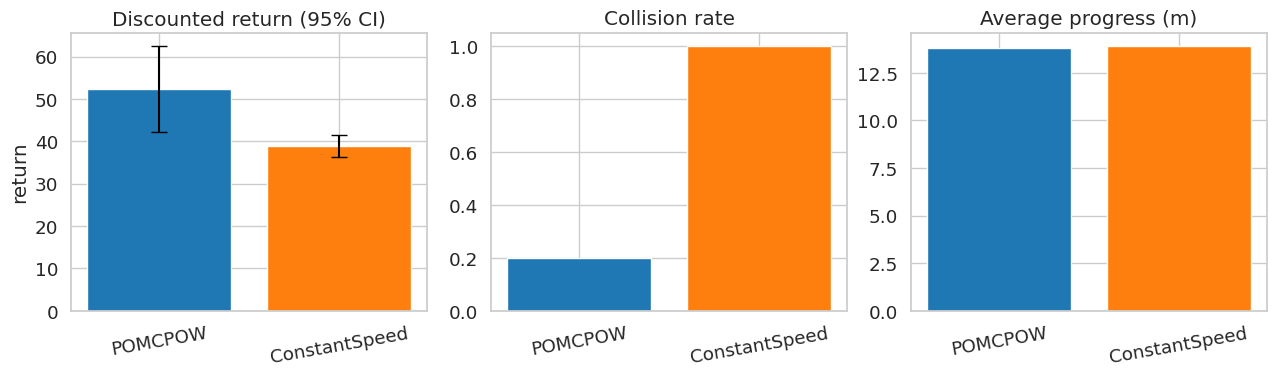

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

policies = statistics_df["policy"].tolist()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Discounted return with 95% CI
means = statistics_df["average_return"].to_numpy(dtype=float)
lower = statistics_df["average_return_ci_lower"].to_numpy(dtype=float)
upper = statistics_df["average_return_ci_upper"].to_numpy(dtype=float)
axes[0].bar(policies, means, yerr=[means - lower, upper - means], capsize=6, color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Discounted return (95% CI)")
axes[0].set_ylabel("return")

# Safety vs progress
axes[1].bar(policies, statistics_df["collision_rate"].to_numpy(dtype=float), color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Collision rate")
axes[1].set_ylim(0, 1.05)

axes[2].bar(policies, statistics_df["average_progress"].to_numpy(dtype=float), color=["#1f77b4", "#ff7f0e"])
axes[2].set_title("Average progress (m)")

for ax in axes:
    ax.tick_params(axis="x", rotation=10)
fig.tight_layout()
plt.show()

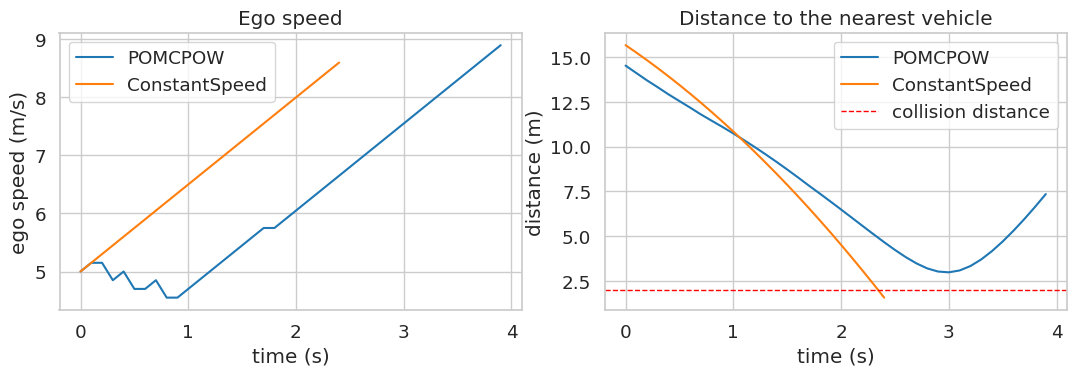

In [8]:
# What the planners actually did: ego speed and the distance to the nearest vehicle, episode 0.
def speed_and_distance(history):
    speeds, distances = [], []
    for step in history.history:
        state = np.asarray(step.state, dtype=float)
        speeds.append(float(np.hypot(state[3], state[4])))
        rows = state[EGO_STATE_WIDTH : EGO_STATE_WIDTH + K * AGENT_SLOT_WIDTH].reshape(
            K, AGENT_SLOT_WIDTH
        )
        present = rows[rows[:, 0] == 1.0]
        distances.append(
            float(np.min(np.hypot(present[:, 1], present[:, 2]))) if len(present) else np.nan
        )
    return np.array(speeds), np.array(distances)


fig, (ax_speed, ax_distance) = plt.subplots(1, 2, figsize=(11, 4))
for policy_name, histories in results["NuPlanPOMDP"].items():
    speeds, distances = speed_and_distance(histories[0])
    time_axis = np.arange(len(speeds)) * DT
    ax_speed.plot(time_axis, speeds, label=policy_name)
    ax_distance.plot(time_axis, distances, label=policy_name)

ax_speed.set(xlabel="time (s)", ylabel="ego speed (m/s)", title="Ego speed")
ax_distance.axhline(2.0, color="red", ls="--", lw=1, label="collision distance")
ax_distance.set(
    xlabel="time (s)", ylabel="distance (m)", title="Distance to the nearest vehicle"
)
ax_speed.legend()
ax_distance.legend()
fig.tight_layout()
plt.show()

The baseline's episodes end early: it accelerates until the nearest vehicle crosses the 2 m collision
distance and the world terminates the episode — hence its high `average_speed` and low
`average_actual_num_steps`. POMCPOW gives up speed to hold a margin and survives the horizon.

That is the trade-off the metric set exists to expose: neither `average_progress` nor `average_speed`
alone separates a good driver from a reckless one, and `collision_rate` alone is trivially optimised
by standing still. Exact numbers move between runs (particle sampling and the tree search are
stochastic, and the synthetic scenario is randomised per episode) — for a claim you would report,
raise `NUM_EPISODES` until the confidence intervals are tight enough to separate the policies.

## 6. Evaluating on real nuPlan scenarios

Everything above is unchanged for the real benchmark — only the world construction differs. Supply a
zero-argument `scenario_loader` returning a nuPlan `AbstractScenario` (one element of
`NuPlanScenarioBuilder(...).get_scenarios(scenario_filter, worker)` from the devkit), and the session
drives a genuine closed-loop `Simulation` with IDM background traffic and a tracking controller:

```python
from POMDPPlanners.environments.nuplan_pomdp.nuplan_pomdp import NuPlanPOMDP

world = NuPlanPOMDP(
    discount_factor=GAMMA,
    scenario_loader=load_scenario,   # () -> nuplan AbstractScenario, called once per reset
    max_tracked_agents=K,
    fixed_delta_seconds=DT,
    simulation_horizon=8.0,          # seconds of trajectory handed to the tracker per step
    reactive_agents=True,            # IDM traffic; False replays the logged tracks
    collision_distance=2.0,
    seed=0,
)
```

Requirements: `nuplan-devkit` importable and the nuPlan dataset available (`NUPLAN_DATA_ROOT`,
`NUPLAN_MAPS_ROOT`). To evaluate across *many* scenarios, make `load_scenario` pop from a list —
each episode resets the world, so each episode becomes a different scenario.

For a driven episode plus a rendered bird's-eye-view video, see `nuplan_pomcpow_example.py` at the
repository root, which uses the same world/model/belief triple.

## 7. When is nuPlan the right environment?

Compared with the other environments in this package:

- **Against the toy benchmarks** (`TigerPOMDP`, `LightDarkPOMDP`, `RockSample`, `LaserTag`): nuPlan
  brings a real task distribution — logged urban driving, reactive IDM traffic, and a multi-term
  driving-quality reward — instead of a hand-designed one. Its metrics are the ones a driving paper
  reports (`collision_rate`, progress, near misses), so results transfer to that literature.
- **Against CARLA** (`CarlaPOMDP`): both are forward-only two-environment worlds with the same schema
  and the same planner-side model pattern. The difference is cost and realism *of a different kind* —
  CARLA renders camera/LiDAR from a synthetic town and needs a running server; nuPlan is a
  light, headless, mid-level simulator (no rendering) replaying **real** logs, so it starts fast,
  runs many episodes cheaply, and its traffic is human, not scripted. Choose nuPlan when the question
  is about *planning under partial observability*, and CARLA when the question is about *perception*.
- **Against the Gym-style wrappers** (`CartPole`, `MountainCar`, `SafetyAntVelocity`): nuPlan is
  genuinely partially observed — the ego reads its own proprioception plus a tracked-object list,
  not the world's full ground truth — and it has occlusion, so the value of information is real.

Costs to weigh: it needs the devkit *and* a dataset download, it cannot serve as a generative model
(you must supply one), and it has no photorealistic sensors.

## What's next?

- **Compare planners at scale**: [planners_comparison.ipynb](planners_comparison.ipynb) — the same
  `LocalSimulationsAPI` workflow across several environments.
- **Tune the planner**: [hyperparameter_tuning.ipynb](hyperparameter_tuning.ipynb) — Optuna over
  POMCPOW's `depth`, `k_o`, `alpha_o`, and the model's gap parameters.
- **Swap the dynamics**: subclass `NuPlanModelPOMDP` to search inside a learned world model instead of
  the kinematic one; the observation schema and the belief stay as they are.
- **Inspect the search**: [tree_analysis_debugging.ipynb](tree_analysis_debugging.ipynb).